# Imports

In [1]:
import sys

repo_path = '/Users/zohairshafi/Local Workspace/spectral_nature/'
sys.path.append(repo_path)
from src.utils.alpaca_utils import *


with open(os.path.join(cache_path, 'headers.pkl'), 'rb') as file: 
    headers, paper_header = pkl.load(file)

# Data Collection

In [ ]:
# Import the worker function from a top-level module so it's picklable by child processes
from src.utils.run_symbol_worker import run_symbol

# symbol_list = ['AAPL', 'MSFT', 'QCOM', 'GOOGL', 'AMZN', 'TSLA', 'PINS', 'NFLX', 'NVDA', 'META', 'SPY', 'QQQ'] + ['RIVN', 'CRWV', 'SMR', 'CEG', 'CAT'] + ['GLD']
symbol_list = ['SPY', 'QQQ', 'GLD']

# Progress logging setup
repo_path = '/Users/zohairshafi/Local Workspace/spectral_nature/'
progress_log_path = os.path.join(repo_path, 'cache', 'progress.log')
# Initialize/clear previous log
with open(progress_log_path, 'w') as _f:
    _f.write(f'Progress log started {datetime.utcnow().isoformat()}Z\n')

def log_progress(message: str):
    timestamp = datetime.utcnow().isoformat()
    with open(progress_log_path, 'a') as f:
        f.write(f'[{timestamp}] {message}\n')

# Ensure spawn start method (safer on macOS / notebooks)
try:
    mp.set_start_method('spawn', force=False)
except RuntimeError:
    # Already set in this interpreter
    pass

# Multiprocessing execution block
summaries = []

max_workers = min(8, cpu_count(), len(symbol_list))  # adjust as desired
log_progress(f'Launching process pool max_workers={max_workers} total_symbols={len(symbol_list)}')

with Pool(processes=max_workers) as pool:
    # Bind constant args for each worker using partial (picklable since function is module-level)
    worker_fn = partial(run_symbol, repo_path=repo_path, progress_log_path=progress_log_path)
    total = len(symbol_list)
    for completed, summary in enumerate(pool.imap_unordered(worker_fn, symbol_list), 1):
        summaries.append(summary)
        sym = summary.get('symbol', 'UNKNOWN')
        log_progress(f'COMPLETED symbol={sym} ({completed}/{total})')
        if completed % 2 == 0 or completed == total:
            pct = (completed/total)*100
            log_progress(f'OVERALL progress={completed}/{total} ({pct:0.1f}%)')

summary_df = pd.DataFrame(summaries)*

display(summary_df)
print(f'Progress log written to: {progress_log_path}')

# Data Pre-Processing

In [2]:
symbol_list = ['AAPL', 'MSFT', 'QCOM', 'GOOGL', 'AMZN', 'TSLA', 'PINS', 'NFLX', 'NVDA', 'META', 'SPY', 'QQQ'] + ['RIVN', 'CRWV', 'SMR', 'CEG', 'CAT'] + ['GLD']

data = []
for symbol in tqdm(symbol_list):
    with open(os.path.join(cache_path, 'closed_trades', f'{symbol}_closed_trades.pkl'), 'rb') as file: 
        closed_trades_df = pkl.load(file)
        closed_trades_df['Symbol'] = symbol
        data.append(closed_trades_df)
final_closed_trades_df = pd.concat(data).reset_index(drop = True)

final_closed_trades_df

100%|██████████| 18/18 [00:00<00:00, 63.52it/s]


,entry_date,entry_credit,entry_stock_price,strike,IV Short,IV Long,Delta_Short,Delta_Long,Gamma Short,Gamma Long,...,spread_distance,current_date,return_pct,short_exit_reason,short_exit_date,long_exit_reason,long_exit_date,exit_date,final_pnl,Symbol
0,2024-01-18 05:00:00+00:00,-267.0,188.70,190.0,0.279893,0.225208,0.472493,0.495347,0.038545,0.030355,...,21,2024-02-23 05:00:00+00:00,-1.460674,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-390.0,AAPL
1,2024-01-18 05:00:00+00:00,-189.0,188.70,195.0,0.267601,0.216161,0.284047,0.343305,0.034320,0.029147,...,21,2024-02-23 05:00:00+00:00,-1.190476,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-225.0,AAPL
2,2024-01-18 05:00:00+00:00,-162.0,188.70,180.0,0.293569,0.239996,-0.190367,-0.235592,0.025015,0.021924,...,21,2024-02-23 05:00:00+00:00,-1.697531,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-275.0,AAPL
3,2024-01-18 05:00:00+00:00,-117.0,188.70,175.0,0.308609,0.253223,-0.096354,-0.147773,0.014962,0.015590,...,21,2024-02-23 05:00:00+00:00,-1.410256,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-165.0,AAPL
4,2024-01-19 05:00:00+00:00,-225.0,191.55,195.0,0.269282,0.211442,0.383161,0.424646,0.039276,0.031737,...,21,2024-02-23 05:00:00+00:00,-1.160000,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-261.0,AAPL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111442,2024-12-09 05:00:00+00:00,-320.0,245.37,246.0,0.183525,0.143333,0.451426,0.508454,0.097556,0.044354,...,21,2025-01-03 05:00:00+00:00,-2.578125,Short Expired,2024-12-13 00:00:00+00:00,Long Expired,2025-01-03 00:00:00+00:00,2025-01-03 05:00:00+00:00,-825.0,GLD
1111443,2024-12-09 05:00:00+00:00,-139.0,245.37,254.0,0.198982,0.158698,0.029483,0.222218,0.015183,0.029870,...,21,2025-01-03 05:00:00+00:00,-1.230216,Short Expired,2024-12-13 00:00:00+00:00,Long Expired,2025-01-03 00:00:00+00:00,2025-01-03 05:00:00+00:00,-171.0,GLD
1111444,2024-12-09 05:00:00+00:00,-203.0,245.37,244.0,0.173706,0.138756,-0.349224,-0.401437,0.095286,0.044181,...,21,2025-01-03 05:00:00+00:00,-0.078818,Short Expired,2024-12-13 00:00:00+00:00,Long Expired,2025-01-03 00:00:00+00:00,2025-01-03 05:00:00+00:00,-16.0,GLD
1111445,2024-12-09 05:00:00+00:00,-200.0,245.37,251.0,0.185963,0.156752,0.093972,0.316028,0.040645,0.036135,...,21,2025-01-03 05:00:00+00:00,-1.510000,Short Expired,2024-12-13 00:00:00+00:00,Long Expired,2025-01-03 00:00:00+00:00,2025-01-03 05:00:00+00:00,-302.0,GLD


In [ ]:
data = {
    'Delta Long' : final_closed_trades_df['Delta_Long'],
    'Delta Short' : final_closed_trades_df['Delta_Short'],
    'Delta Ratio' : final_closed_trades_df['Delta_Long'] / final_closed_trades_df['Delta_Short'],
    'Delta Difference' : final_closed_trades_df['Delta_Long'] - final_closed_trades_df['Delta_Short'],
    'Gamma Long' : final_closed_trades_df['Gamma Long'],
    'Gamma Short' : final_closed_trades_df['Gamma Short'],
    'Gamma Difference' : final_closed_trades_df['Gamma Long'] - final_closed_trades_df['Gamma Short'],
    'Gamma Ratio' : final_closed_trades_df['Gamma Long'] / final_closed_trades_df['Gamma Short'],
    'IV Long' : final_closed_trades_df['IV Long'],
    'IV Short' : final_closed_trades_df['IV Short'],
    'IV Difference' : final_closed_trades_df['IV Long'] - final_closed_trades_df['IV Short'],
    'IV Ratio' : final_closed_trades_df['IV Long'] / final_closed_trades_df['IV Short'],
    'Theta Long' : final_closed_trades_df['Theta Long'],
    'Theta Short' : final_closed_trades_df['Theta Short'],
    'Theta Difference' : final_closed_trades_df['Theta Long'] - final_closed_trades_df['Theta Short'],
    'Theta Ratio' : final_closed_trades_df['Theta Long'] / final_closed_trades_df['Theta Short'],
    'Vega Long' : final_closed_trades_df['Vega Long'],
    'Vega Short' : final_closed_trades_df['Vega Short'],
    'Vega Difference': final_closed_trades_df['Vega Long'] - final_closed_trades_df['Vega Short'],
    'Vega Ratio' : final_closed_trades_df['Vega Long'] / final_closed_trades_df['Vega Short'],
    'Forward Factor' : final_closed_trades_df['forward_factor'],
    'Spread' : np.abs(final_closed_trades_df['spread_distance']),
    'Short DTE': np.abs((final_closed_trades_df['current_date'] - final_closed_trades_df['short_expiry']).dt.days),
    'Strike Deviation' : 100 * np.abs(final_closed_trades_df['entry_stock_price'] - final_closed_trades_df['strike']) / final_closed_trades_df['strike'],
    'PnL' : final_closed_trades_df['final_pnl'],
    'PnL Percent' : [-1 if x <= -1 else x for x in final_closed_trades_df['return_pct']],
    'Option Type' : [1 if x == 'call' else 0 for x in final_closed_trades_df['option_type']],
    'Symbol' : final_closed_trades_df['Symbol'], 
    # 'Day of Year': final_closed_trades_df['entry_date'].dt.dayofyear,
}

data = pd.DataFrame(data)
display (data)


,Delta Long,Delta Short,Delta Ratio,Delta Difference,Gamma Long,Gamma Short,Gamma Difference,Gamma Ratio,IV Long,IV Short,...,Vega Difference,Vega Ratio,Forward Factor,Spread,Short DTE,Strike Deviation,PnL,PnL Percent,Option Type,Symbol
0,0.495347,0.472493,1.048369,0.022854,0.030355,0.038545,-0.008190,0.787518,0.225208,0.279893,...,0.084535,1.559146,55.725466,21,21,0.684211,-390.0,-1.000000,1,AAPL
1,0.343305,0.284047,1.208621,0.059258,0.029147,0.034320,-0.005173,0.849276,0.216161,0.267601,...,0.088550,1.687717,54.150627,21,21,3.230769,-225.0,-1.000000,1,AAPL
2,-0.235592,-0.190367,1.237564,-0.045224,0.021924,0.025015,-0.003091,0.876444,0.239996,0.293569,...,0.078632,1.761895,49.535743,21,21,4.833333,-275.0,-1.000000,0,AAPL
3,-0.147773,-0.096354,1.533642,-0.051419,0.015590,0.014962,0.000628,1.041955,0.253223,0.308609,...,0.071527,2.102501,48.177034,21,21,7.828571,-165.0,-1.000000,0,AAPL
4,0.424646,0.383161,1.108272,0.041485,0.031737,0.039276,-0.007539,0.808052,0.211442,0.269282,...,0.089582,1.630299,62.398371,21,21,1.769231,-261.0,-1.000000,1,AAPL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111442,0.508454,0.451426,1.126329,0.057028,0.044354,0.097556,-0.053202,0.454653,0.143333,0.183525,...,0.156029,2.575583,34.322694,21,21,0.256098,-825.0,-1.000000,1,GLD
1111443,0.222218,0.029483,7.537140,0.192735,0.029870,0.015183,0.014687,1.967312,0.158698,0.198982,...,0.173664,11.353923,30.845404,21,21,3.397638,-171.0,-1.000000,1,GLD
1111444,-0.401437,-0.349224,1.149509,-0.052212,0.044181,0.095286,-0.051105,0.463671,0.138756,0.173706,...,0.154733,2.671763,30.590728,21,21,0.561475,-16.0,-0.078818,0,GLD
1111445,0.316028,0.093972,3.363005,0.222056,0.036135,0.040645,-0.004511,0.889028,0.156752,0.185963,...,0.185552,5.425122,22.245967,21,21,2.243028,-302.0,-1.000000,1,GLD


In [4]:
# 1) Build features and target (binary: positive PnL)
feature_cols = [c for c in data.columns
                if c not in ['PnL', 'PnL Percent', 'Symbol']
                and pd.api.types.is_numeric_dtype(data[c])]

# Assemble modeling frame and clean
df_model = data[feature_cols + ['PnL', 'PnL Percent']].copy()
df_model['label'] = (df_model['PnL'] > 0).astype(int)
df_model['regression_label'] = data['PnL Percent']
df_model = df_model.drop(columns=['PnL', 'PnL Percent'])
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

# Stabilize range of regression target by removing outliers
df_model = df_model[(df_model['regression_label'] <= -0.05) |
                    (df_model['regression_label'] >= 0.05)]

df_model = df_model[(df_model['regression_label'] >= -80) &
                    (df_model['regression_label'] <= 80)]

# Calls only 
# df_model = df_model[df_model['Option Type'] == 1]

# Puts only
# df_model = df_model[df_model['Option Type'] == 0]

X = df_model[feature_cols].to_numpy(dtype=np.float32)
y = df_model['label'].to_numpy(dtype=np.int64)
y_reg = df_model['regression_label'].to_numpy(dtype=np.float32)

test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test, y_reg_train, y_reg_test = train_test_split(X,
                                                    y,
                                                    y_reg,
                                                    test_size=test_size,
                                                    random_state=random_state,
                                                    stratify=y)

# 3) Standardize using train statistics (manual, no sklearn dependency)
mean_ = X_train.mean(axis = 0)
std_ = X_train.std(axis = 0) + 1e-8
X_train = (X_train - mean_) / std_
X_test = (X_test - mean_) / std_

min_reg_scale = np.min(y_reg_train)
denom_reg_scale = np.ptp(y_reg_train) + 1e-8

y_reg_train = (y_reg_train - min_reg_scale) / denom_reg_scale
y_reg_test = (y_reg_test - min_reg_scale) / denom_reg_scale
zero_point = (0 - min_reg_scale) / denom_reg_scale



# 4) Build PyTorch datasets and loaders
batch_size = 256000
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train.astype(np.float32)), torch.from_numpy(y_reg_train.astype(np.float32)))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test.astype(np.float32)), torch.from_numpy(y_reg_test.astype(np.float32)))
train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_ds, batch_size = batch_size, shuffle = False)


In [7]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = MultiModel(in_dim = X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 5e-4)

# Handle class imbalance via pos_weight in BCEWithLogitsLoss
pos = float((y_train > 0.5).sum())
neg = float((y_train <= 0.5).sum())

pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)

def mean_absolute_error(y_pred, y_true):

    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
    reg_weights = torch.ones_like(y_true, device=device)
    reg_weights[y_true >= zero_point] = pos_weight

    return torch.mean(torch.abs(y_pred - y_true) * reg_weights)

criterion_regression = mean_absolute_error



Epoch 001 | Loss = 3.6115 | Train_acc = 0.634 | Train_MAE = 0.9769 | Train_Corr = -0.087

Epoch 005 | Loss = 2.2041 | Train_acc = 0.681 | Train_MAE = 0.6269 | Train_Corr = 0.009

Epoch 010 | Loss = 1.8275 | Train_acc = 0.704 | Train_MAE = 0.4769 | Train_Corr = 0.014

Epoch 015 | Loss = 1.5931 | Train_acc = 0.713 | Train_MAE = 0.3612 | Train_Corr = 0.013

Epoch 020 | Loss = 1.4089 | Train_acc = 0.717 | Train_MAE = 0.2657 | Train_Corr = 0.015

Epoch 025 | Loss = 1.2544 | Train_acc = 0.720 | Train_MAE = 0.1832 | Train_Corr = 0.022

Epoch 030 | Loss = 1.1226 | Train_acc = 0.722 | Train_MAE = 0.1129 | Train_Corr = 0.032

Epoch 035 | Loss = 1.0147 | Train_acc = 0.724 | Train_MAE = 0.0548 | Train_Corr = 0.060

Epoch 040 | Loss = 0.9478 | Train_acc = 0.725 | Train_MAE = 0.0235 | Train_Corr = 0.126

Epoch 045 | Loss = 0.9374 | Train_acc = 0.726 | Train_MAE = 0.0183 | Train_Corr = 0.254

Epoch 050 | Loss = 0.9264 | Train_acc = 0.729 | Train_MAE = 0.0164 | Train_Corr = 0.277

Epoch 055 | Loss = 

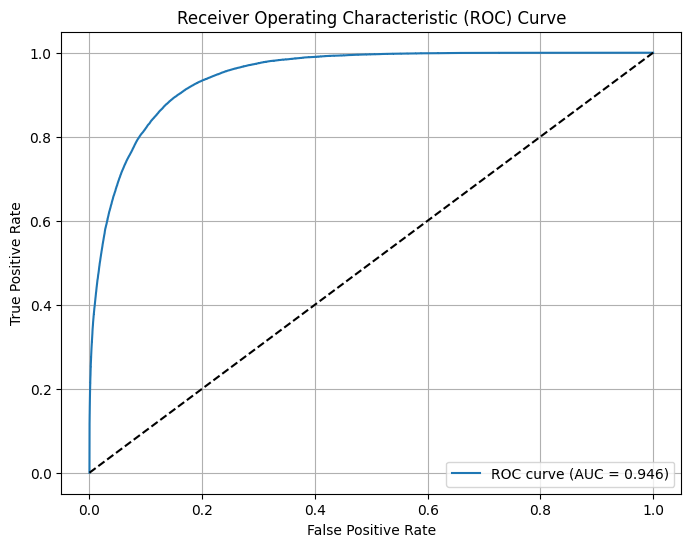

In [8]:
epochs = 500
patience = 5  # epochs to wait for improvement
min_delta = 1e-4  # minimum change to qualify as improvement
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb, yb_reg in train_loader:
        
        xb = xb.to(device)
        yb = yb.to(device).flatten()
        yb_reg = yb_reg.to(device).flatten()

        optimizer.zero_grad()    
        logits = model(xb)
        loss = criterion(logits[:, 0], yb)
        reg_loss = criterion_regression(logits[:, 1], yb_reg)
        total_loss = (1 * loss) + (1 * reg_loss)
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    if epoch % 5 == 0 or epoch == 1:
        with torch.no_grad():
            logits = model(torch.from_numpy(X_train).to(device))
            preds = (torch.sigmoid(logits[:, 0]).cpu().numpy().ravel() >= 0.5).astype(int)
            acc = (preds == y_train).mean() if len(y_train) else float('nan')
            mae = torch.mean(torch.abs(logits[:, 1].cpu() - torch.from_numpy(y_reg_train))).item()
            corr = np.corrcoef(logits[:, 1].cpu().numpy().ravel(), y_reg_train)[0, 1]

        print(f'\nEpoch {epoch:03d} | Loss = {epoch_loss:.4f} | Train_acc = {acc:.3f} | Train_MAE = {mae:.4f} | Train_Corr = {corr:.3f}')

    # ----- Validation (for early stopping) -----
#     model.eval()
#     val_running_loss = 0.0
#     acc = []
#     with torch.no_grad():
#         for xb, yb, yb_reg in test_loader:
#             xb = xb.to(device)
#             yb = yb.to(device).flatten()
#             yb_reg = yb_reg.to(device).flatten()
#             logits = model(xb)
#             v_loss_cls = criterion(logits[:, 0], yb)
#             v_loss_reg = criterion_regression(logits[:, 1], yb_reg)
#             val_running_loss += (v_loss_cls + v_loss_reg).item() * xb.size(0)
#             preds_test = (torch.sigmoid(logits[:, 0]).cpu().numpy().ravel() >= 0.5).astype(int)
#             acc.append((preds_test == yb.detach().cpu().numpy()).mean() if len(yb) else float('nan'))
#     val_loss = val_running_loss / len(test_loader.dataset)
#     print (f'Epoch {epoch:03d} | Loss = {total_loss.item():.4f} | Classification Loss: {loss.item():.4f} | Regression Loss: {reg_loss.item():.4f} | Test Accuracy: {np.mean(np.array(acc))}', end='\r')

#     # Check improvement
#     if val_loss < (best_val_loss - min_delta):
#         best_val_loss = val_loss
#         best_state = copy.deepcopy(model.state_dict())
#         epochs_no_improve = 0
#     else:
#         epochs_no_improve += 1
#         if epochs_no_improve >= patience:
#             print(f'Early stopping at epoch {epoch} (no improvement for {patience} epochs). Best val loss: {best_val_loss:.4f}')
#             break

# # Restore best model (if captured)
# if best_state is not None:
#     model.load_state_dict(best_state)

# 7) Evaluate on test set
model.eval()
with torch.no_grad():
    logits = model(torch.from_numpy(X_test).to(device))
    probs = torch.sigmoid(logits[:, 0]).cpu().numpy().ravel()
    y_pred = (probs >= 0.5).astype(int)
    y_reg_pred = logits[:, 1].cpu().numpy().ravel()
test_acc = (y_pred == y_test).mean() if len(y_test) else float('nan')
reg_test_mae = torch.mean(torch.abs(torch.tensor(y_reg_pred) - torch.tensor(y_reg_test))).item() if len(y_reg_test) else float('nan')
print(f'Test regression MAE: {reg_test_mae:.4f}')
print(f'Test accuracy: {test_acc:.3f}  (n_test={len(y_test)})')

# Precision, Recall, F1
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
print(f'Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}')

roc_auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()



# # Show learned weights with feature names
# coef = model.linear.weight[0].detach().cpu().numpy().ravel()
# bias = float(model.linear.bias[0].detach().cpu().numpy().ravel())

# coef_reg = model.linear.weight[1].detach().cpu().numpy().ravel()
# bias_reg = float(model.linear.bias[1].detach().cpu().numpy().ravel())

# coef_table = pd.DataFrame({'Features': feature_cols, 'Classification Weights': coef, 'Regression Weights': coef_reg}).sort_values('Classification Weights', ascending=False).reset_index(drop=True)
# print('Bias:', bias)
# print('Regression Bias:', bias_reg)
# display(coef_table)

torch.save(model.state_dict(), os.path.join(cache_path, 'alpaca_multi_model_calendar_spread_v2.pth'))


In [9]:
# torch.save(model.state_dict(), os.path.join(cache_path, 'alpaca_multi_model_calendar_spread_v2.pth'))

# with open(os.path.join(cache_path, 'alpaca_multi_model_calendar_spread_v2_params.pkl'), 'wb') as file: 
#     pkl.dump({
#         'mean_': mean_,
#         'std_': std_,
#         'min_reg_scale': min_reg_scale,
#         'denom_reg_scale': denom_reg_scale
#     }, file)

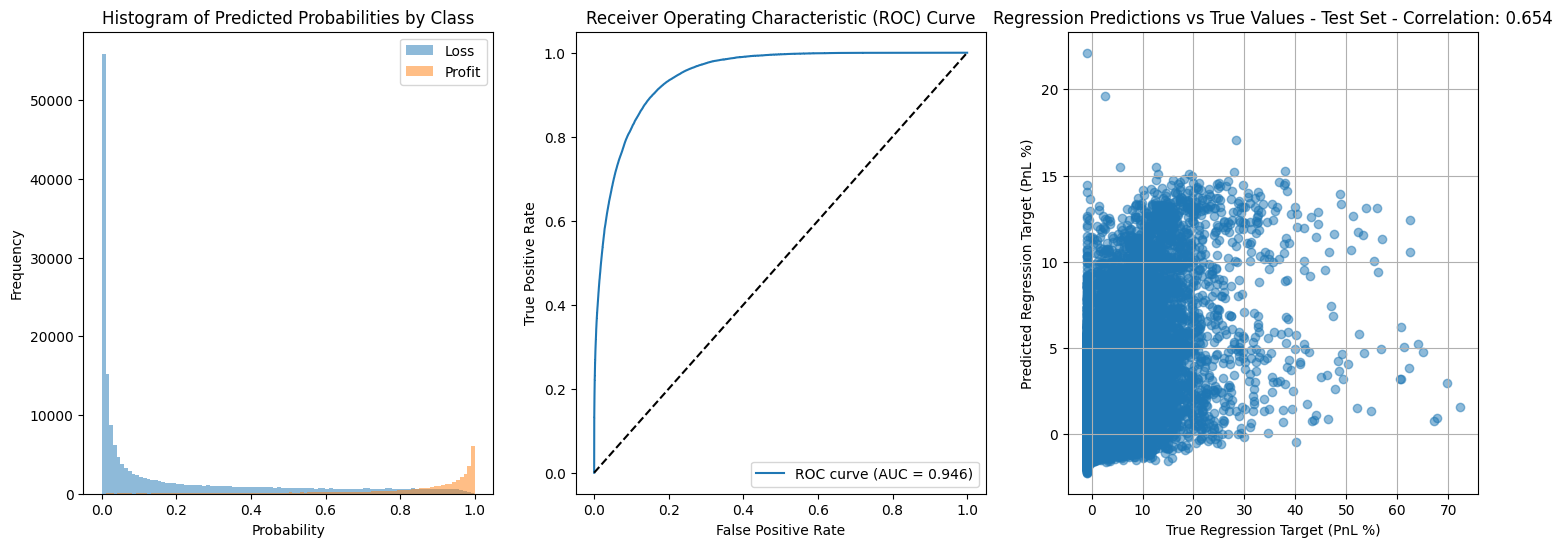

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
axs[0].hist(probs[np.where(y_test == 0)[0]], bins=100, alpha=0.5, label='Loss')
axs[0].hist(probs[np.where(y_test == 1)[0]], bins=100, alpha=0.5, label='Profit')
axs[0].set_xlabel('Probability')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Histogram of Predicted Probabilities by Class')
axs[0].legend()

axs[1].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
axs[1].plot([0, 1], [0, 1], 'k--')
axs[1].set_xlabel('False Positive Rate')
axs[1].set_ylabel('True Positive Rate')
axs[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axs[1].legend()

axs[2].scatter(invert_reg_scale(y_reg_test, denom_reg_scale, min_reg_scale), invert_reg_scale(y_reg_pred, denom_reg_scale, min_reg_scale), alpha=0.5)
axs[2].set_xlabel('True Regression Target (PnL %)')
axs[2].set_ylabel('Predicted Regression Target (PnL %)')
axs[2].set_title(f'Regression Predictions vs True Values - Test Set - Correlation: {np.corrcoef(y_reg_test, y_reg_pred)[0, 1]:.3f}')
axs[2].grid()
plt.show()

Per-symbol ROC AUC (NaN = not computable due to single class):


,Symbol,n,pos_rate,roc_auc
0,NFLX,47617,0.208623,0.930463
1,GLD,58552,0.183102,0.906706
2,RIVN,3557,0.140849,0.856523
3,NVDA,97557,0.158277,0.830908
4,PINS,18448,0.210592,0.793644
5,SMR,4602,0.178183,0.779059
6,SPY,214445,0.151722,0.775530
7,QQQ,143857,0.173165,0.742290
8,MSFT,88499,0.143493,0.732737
9,CEG,4854,0.235682,0.729110



Per-symbol + Option Type ROC AUC (NaN = not computable due to single class):


,Symbol,OptionType,n,pos_rate,roc_auc
0,AAPL,call,23441,0.223668,0.626359
1,AAPL,put,30099,0.119805,0.577751
2,AMZN,call,19457,0.281749,0.653261
3,AMZN,put,32171,0.101582,0.484405
4,CAT,call,7465,0.432686,0.588247
5,CAT,put,11054,0.172879,0.596630
6,CEG,call,2349,0.410387,0.522544
7,CEG,put,2505,0.071856,0.371778
8,CRWV,call,2605,0.482150,0.422511
9,CRWV,put,1772,0.037810,0.796945


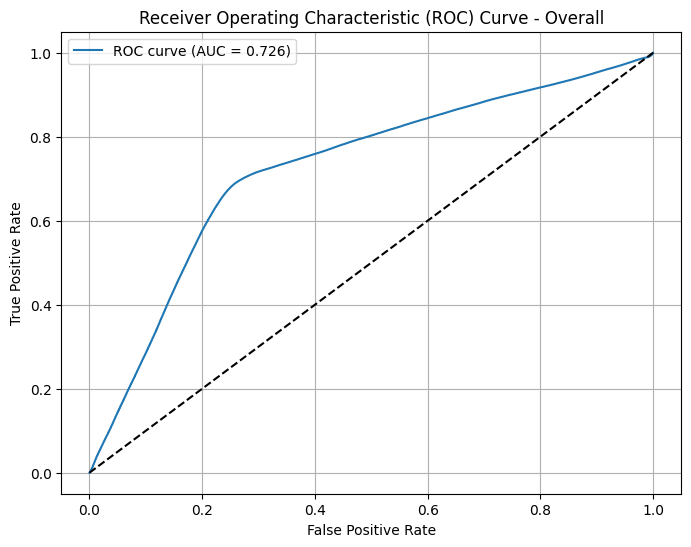

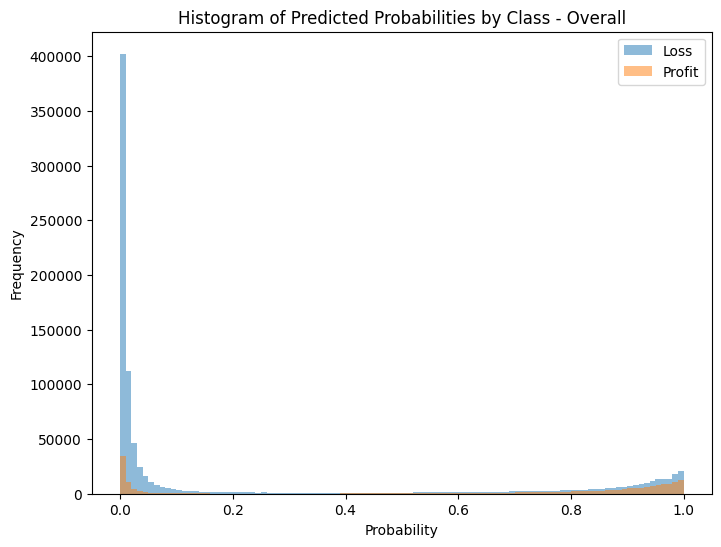

In [11]:
# Test set 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model_path='/Users/zohairshafi/Local Workspace/spectral_nature/cache'
model_name='alpaca_multi_model_calendar_spread_v2.pth'
params_name='alpaca_multi_model_calendar_spread_params_v2.pkl'

model = MultiModel(in_dim = len(feature_cols)).to(device)
model.load_state_dict(torch.load(os.path.join(model_path, model_name), map_location=device))
with open(os.path.join(model_path, params_name), 'rb') as file: 
    model_params = pkl.load(file)

mean_ = model_params['mean_']
std_ = model_params['std_']
min_reg_scale = model_params['min_reg_scale']
denom_reg_scale = model_params['denom_reg_scale']

model.eval()

# Build modeling frame for inference including Symbol, Option Type, and PnL for per-symbol metrics
df_model = data[feature_cols + ['PnL', 'Symbol']].copy()

# Clean and standardize
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols + ['PnL', 'Symbol'])
X_options = df_model[feature_cols].to_numpy(dtype=np.float32)
X_options = (X_options - mean_) / std_

# Inference
logits = model(torch.from_numpy(X_options).to(device))
probs = torch.sigmoid(logits[:, 0]).detach().cpu().numpy().ravel()
y_reg_pred = logits[:, 1].detach().cpu().numpy().ravel()
y_reg_pred_original = invert_reg_scale(y_reg_pred, denom_reg_scale, min_reg_scale)

# Overall metrics
df_model['prob'] = probs
df_model['label'] = (df_model['PnL'] > 0).astype(int)
y_overall = df_model['label'].to_numpy()

# Handle degenerate case where only one class exists overall
roc_auc = np.nan
if len(np.unique(y_overall)) > 1:
    roc_auc = roc_auc_score(y_overall, probs)
    fpr, tpr, _ = roc_curve(y_overall, probs)
else:
    fpr, tpr = np.array([0, 1]), np.array([0, 1])

# Per-symbol AUC characteristics
rows = []
for sym, grp in df_model.groupby('Symbol'):
    y_sym = grp['label'].to_numpy()
    p_sym = grp['prob'].to_numpy()
    if len(np.unique(y_sym)) < 2:
        sym_auc = np.nan  # cannot compute ROC AUC with single class
    else:
        sym_auc = roc_auc_score(y_sym, p_sym)
    rows.append({
        'Symbol': sym,
        'n': int(len(grp)),
        'pos_rate': float(y_sym.mean()) if len(y_sym) else np.nan,
        'roc_auc': float(sym_auc) if sym_auc == sym_auc else np.nan  # keep NaN if not computable
    })
auc_by_symbol = pd.DataFrame(rows).sort_values(['roc_auc', 'n'], ascending=[False, False])

# Per-symbol & option type AUC characteristics (Option Type may be part of feature_cols)
# If Option Type exists in df_model columns proceed; else skip gracefully
if 'Option Type' in df_model.columns:
    rows_opt = []
    # Map numeric to string for readability
    type_map = {1: 'call', 0: 'put'}
    for (sym, opt_type), grp in df_model.groupby(['Symbol', 'Option Type']):
        y_grp = grp['label'].to_numpy()
        p_grp = grp['prob'].to_numpy()
        if len(np.unique(y_grp)) < 2:
            grp_auc = np.nan
        else:
            grp_auc = roc_auc_score(y_grp, p_grp)
        rows_opt.append({
            'Symbol': sym,
            'OptionTypeRaw': int(opt_type),
            'OptionType': type_map.get(int(opt_type), str(opt_type)),
            'n': int(len(grp)),
            'pos_rate': float(y_grp.mean()) if len(y_grp) else np.nan,
            'roc_auc': float(grp_auc) if grp_auc == grp_auc else np.nan
        })
    auc_by_symbol_option = pd.DataFrame(rows_opt).sort_values(['roc_auc', 'n'], ascending=[False, False])
else:
    auc_by_symbol_option = pd.DataFrame(columns=['Symbol','OptionType','n','pos_rate','roc_auc'])

# Display per-symbol table
print('Per-symbol ROC AUC (NaN = not computable due to single class):')
display(auc_by_symbol.reset_index(drop=True))

print('\nPer-symbol + Option Type ROC AUC (NaN = not computable due to single class):')
auc_by_symbol_option = auc_by_symbol_option.drop(columns=['OptionTypeRaw'])
auc_by_symbol_option.sort_values(['Symbol', 'OptionType'], inplace=True)
display(auc_by_symbol_option.reset_index(drop=True))

# Existing overall visualizations
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})' if roc_auc == roc_auc else 'ROC curve (AUC = N/A)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Overall')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(df_model.loc[y_overall == 0, 'prob'], bins=100, alpha=0.5, label='Loss')
plt.hist(df_model.loc[y_overall == 1, 'prob'], bins=100, alpha=0.5, label='Profit')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted Probabilities by Class - Overall')
plt.legend()
plt.show()

# Backtest Strategy Two

In [5]:
timeframe = '1D'
# overall_results = []
symbol_list = ['QQQ'] + ['RIVN', 'CRWV', 'SMR', 'CEG', 'CAT'] + ['GLD']

for symbol in symbol_list:

    with open(os.path.join(cache_path, f'options/options_cache_{symbol}_{timeframe}.pkl'), 'rb') as file: 
        options_df = pkl.load(file)
    with open(os.path.join(cache_path, f'options/list_of_options_dataframes_{symbol}.pkl'), 'rb') as file:
        list_of_options_dataframes = pkl.load(file)
        
    results = {}
    skipped = 0

    for current_date in tqdm(list_of_options_dataframes.keys()):
        for options_idx in range(len(list_of_options_dataframes[current_date])):
            
            try:
                short = list_of_options_dataframes[current_date][options_idx]['Symbol'].values[0]
                long = list_of_options_dataframes[current_date][options_idx]['Symbol'].values[1]

                df1 = options_df[short].copy()
                df2 = options_df[long].copy()

                # Compute expiration dates once
                short_expiry = pd.to_datetime(df1['Expiration Date'].iloc[0]).date()
                long_expiry = pd.to_datetime(df2['Expiration Date'].iloc[0]).date()

                intersection = set(df1['Current Date'].dt.date).intersection(set(df2['Current Date'].dt.date))
                long_difference = set(df2['Current Date'].dt.date) - intersection

                entry_price = - (df1[df1['Current Date'].dt.date == current_date.date()]['Current Option Price'].values[0] - df2[df2['Current Date'].dt.date == current_date.date()]['Current Option Price'].values[0])
                short_expiry_price = -(df1.iloc[-1]['Current Option Price'] - df2[df2['Current Date'].dt.date == df1.iloc[-1]['Current Date'].date()]['Current Option Price']).values[0]
                long_expiry_price = df2.iloc[-1]['Current Option Price']

                long_profit = long_expiry_price - entry_price
                short_profit = short_expiry_price - entry_price
                max_profit = max(long_profit, short_profit)
                min_profit = min(long_profit, short_profit)

                data = {
                    'Delta Long' : list_of_options_dataframes[current_date][options_idx]['Delta'][1],
                    'Delta Short' : list_of_options_dataframes[current_date][options_idx]['Delta'][0],
                    'Delta Ratio' : list_of_options_dataframes[current_date][options_idx]['Delta'][1] / list_of_options_dataframes[current_date][options_idx]['Delta'][0],
                    'Delta Difference' : list_of_options_dataframes[current_date][options_idx]['Delta'][1] - list_of_options_dataframes[current_date][options_idx]['Delta'][0],
                    'Gamma Long' : list_of_options_dataframes[current_date][options_idx]['Gamma'][1],
                    'Gamma Short' : list_of_options_dataframes[current_date][options_idx]['Gamma'][0],
                    'Gamma Difference' : list_of_options_dataframes[current_date][options_idx]['Gamma'][1] - list_of_options_dataframes[current_date][options_idx]['Gamma'][0],
                    'Gamma Ratio' : list_of_options_dataframes[current_date][options_idx]['Gamma'][1] / list_of_options_dataframes[current_date][options_idx]['Gamma'][0],
                    'IV Long' : list_of_options_dataframes[current_date][options_idx]['IV'][1],
                    'IV Short' : list_of_options_dataframes[current_date][options_idx]['IV'][0],
                    'IV Difference' : list_of_options_dataframes[current_date][options_idx]['IV'][1] - list_of_options_dataframes[current_date][options_idx]['IV'][0],
                    'IV Ratio' : list_of_options_dataframes[current_date][options_idx]['IV'][1] / list_of_options_dataframes[current_date][options_idx]['IV'][0],
                    'Theta Long' : list_of_options_dataframes[current_date][options_idx]['Theta'][1],
                    'Theta Short' : list_of_options_dataframes[current_date][options_idx]['Theta'][0],
                    'Theta Difference' : list_of_options_dataframes[current_date][options_idx]['Theta'][1] - list_of_options_dataframes[current_date][options_idx]['Theta'][0],
                    'Theta Ratio' : list_of_options_dataframes[current_date][options_idx]['Theta'][1] / list_of_options_dataframes[current_date][options_idx]['Theta'][0],
                    'Vega Long' : list_of_options_dataframes[current_date][options_idx]['Vega'][1],
                    'Vega Short' : list_of_options_dataframes[current_date][options_idx]['Vega'][0],
                    'Vega Difference': list_of_options_dataframes[current_date][options_idx]['Vega'][1] - list_of_options_dataframes[current_date][options_idx]['Vega'][0],
                    'Vega Ratio' : list_of_options_dataframes[current_date][options_idx]['Vega'][1] / list_of_options_dataframes[current_date][options_idx]['Vega'][0],
                    'Forward Factor' : list_of_options_dataframes[current_date][options_idx]['Forward Factor'][0],
                    'Spread' : np.abs(list_of_options_dataframes[current_date][options_idx]['DTE'][1] - list_of_options_dataframes[current_date][options_idx]['DTE'][0]),
                    'Short DTE': list_of_options_dataframes[current_date][options_idx]['DTE'][0],
                    'Strike Deviation' : (list_of_options_dataframes[current_date][options_idx]['Current Stock Price'][0] - list_of_options_dataframes[current_date][options_idx]['Strike Price'][0]) / list_of_options_dataframes[current_date][options_idx]['Current Stock Price'][0],
                    'Long PnL' : long_profit,
                    'Short PnL' : short_profit,
                    'PnL Percent' : max_profit / abs(entry_price),
                    'Option Type' : list_of_options_dataframes[current_date][options_idx]['Type'][0],
                }

                results[f'{str(current_date.date())}|{short}|{long}'] = data
            except Exception as e:
                skipped += 1
                continue

    print (f'Total Skipped Trades: {skipped}')
    results_df = pd.DataFrame(results).T
    results_df.reset_index(inplace=True)
    results_df.rename(columns={'index': 'Trade_ID'}, inplace=True)
    overall_results.append(results_df)

overall_results_df = pd.concat(overall_results)

100%|██████████| 476/476 [14:24<00:00,  1.82s/it]


Total Skipped Trades: 19562


100%|██████████| 475/475 [00:28<00:00, 16.91it/s]


Total Skipped Trades: 870


100%|██████████| 165/165 [00:32<00:00,  5.01it/s]


...

Total Skipped Trades: 3404


100%|██████████| 475/475 [00:58<00:00,  8.15it/s]


Total Skipped Trades: 5221


100%|██████████| 476/476 [07:24<00:00,  1.07it/s]


Total Skipped Trades: 30123


In [7]:
# with open(os.path.join(cache_path, f'options/train_data.pkl'), 'wb') as file: 
#     pkl.dump(overall_results_df, file)

In [2]:
with open(os.path.join(cache_path, f'options/train_data.pkl'), 'rb') as file: 
    overall_results_df = pkl.load(file)
data = overall_results_df
data['Option Type'] = data['Option Type'].map({'call': 1, 'put': 0})

In [2]:
# class OptionModel(nn.Module):
#     def __init__(self, in_dim = 1, hidden_dim = 4, ):
#         super().__init__()

#         self.lin_one = nn.Linear(in_dim, hidden_dim)
#         self.lin_two = nn.Linear(hidden_dim, hidden_dim)
#         self.lin_three = nn.Linear(hidden_dim, hidden_dim)
#         self.lin_four = nn.Linear(hidden_dim, hidden_dim)

#         self.log_lin_one = nn.Linear(in_dim, hidden_dim)
#         self.log_lin_two = nn.Linear(hidden_dim, hidden_dim)
#         self.log_lin_three = nn.Linear(hidden_dim, hidden_dim)
#         self.log_lin_four = nn.Linear(hidden_dim, hidden_dim)

#         self.out = nn.Linear(hidden_dim, 2)
        
#         self.dropout = nn.Dropout(p = 0.3)

#         self.bn1 = nn.BatchNorm1d(hidden_dim)
#         self.bn2 = nn.BatchNorm1d(hidden_dim)
#         self.bn3 = nn.BatchNorm1d(hidden_dim)
#         self.bn4 = nn.BatchNorm1d(hidden_dim)

#         self.log_bn1 = nn.BatchNorm1d(hidden_dim)
#         self.log_bn2 = nn.BatchNorm1d(hidden_dim)
#         self.log_bn3 = nn.BatchNorm1d(hidden_dim)
#         self.log_bn4 = nn.BatchNorm1d(hidden_dim)


#     def forward(self, x):

#         # Block One
#         b1 = self.lin_one(x)
#         b1 = self.bn1(b1)
#         b1 = torch.relu(b1)
#         b1 = self.dropout(b1)

#         # Log Skip Connection
#         b2 = torch.log(x)
#         b2 = self.log_lin_one(b2)
#         b2 = torch.exp(b2)
#         b2 = self.log_bn1(b2)
#         b2 = torch.relu(b2)
        
#         # Block Two
#         b1 = self.lin_two(b1 + b2)
#         b1 = self.bn2(b1)
#         b1 = torch.relu(b1)
#         b1 = self.dropout(b1) + 1e-6

#         # # # Log Skip Connection
#         # b2 = torch.log(b1)
#         # b2 = self.log_lin_two(b2)
#         # b2 = torch.exp(b2)
#         # b2 = self.log_bn2(b2)
#         # b2 = torch.relu(b2)

#         # Block Three
#         b1 = self.lin_three(b1 + b2)
#         b1 = self.bn3(b1)
#         b1 = torch.relu(b1)
#         b1 = self.dropout(b1) + 1e-6

#         # # # Log Skip Connection
#         # b2 = torch.log(b1)
#         # b2 = self.log_lin_three(b2)
#         # b2 = torch.exp(b2)
#         # b2 = self.log_bn3(b2)
#         # b2 = torch.relu(b2)

#         # Block Four
#         b1 = self.log_lin_four(b1)
#         b1 = self.bn4(b1)
#         b1 = torch.relu(b1)
#         b1 = self.dropout(b1) + 1e-6
        
#         # # # Log Skip Connection
#         # b2 = torch.log(b1)
#         # b2 = self.log_lin_four(b2)
#         # b2 = torch.exp(b2)
#         # b2 = self.log_bn4(b2)
#         # b2 = torch.relu(b2)

#         # Out Block
#         b1 = self.out(b1 + b2)

#         return b1
    



In [3]:
model = OptionModel(in_dim=overall_results_df.shape[1] - 4, 
                    hidden_dim = 512, 
                    dropout = 0.3)
print ("Number of Parameters: ", sum([p.numel() for p in model.parameters() if p.requires_grad]))
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 5e-4)

Number of Parameters:  806402


In [4]:
# 1) Build features and target (binary: positive PnL)
feature_cols = [c for c in data.columns
                if c not in ['PnL Percent', 'Trade_ID', 'Long PnL', 'Short PnL']
                ]

# Assemble modeling frame and clean
df_model = data[feature_cols + ['PnL Percent', 'Trade_ID']].copy()

df_model['label'] = (df_model['PnL Percent'] > 0).astype(int)
df_model['regression_label'] = df_model['PnL Percent']
df_model['symbol'] = df_model['Trade_ID'].apply(lambda x: x.split('|')[1][:4])

df_model = df_model.drop(columns=['PnL Percent', 'Trade_ID'])
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

# Stabilize range of regression target by removing outliers
df_model = df_model[(df_model['regression_label'] <= -0.05) |
                    (df_model['regression_label'] >= 0.05)]

df_model = df_model[(df_model['regression_label'] >= -50) &
                    (df_model['regression_label'] <= 50)]


X = df_model[feature_cols].to_numpy(dtype=np.float32)
y = df_model['label'].to_numpy(dtype=np.int64)
y_reg = df_model['regression_label'].to_numpy(dtype=np.float32)
symbols = df_model['symbol'].to_numpy()
strat = [str(a) + '_' + str(b) for a, b in zip(y, symbols)]

test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test, y_reg_train, y_reg_test = train_test_split(X,
                                                    y,
                                                    y_reg,
                                                    test_size=test_size,
                                                    random_state=random_state,
                                                    stratify=strat)

# 3) Standardize features using train mean/variance (z-score)
mean_x_train = X_train.mean(axis=0)
std_x_scale = X_train.std(axis=0) + 1e-8
X_train = (X_train - mean_x_train) / std_x_scale
X_test = (X_test - mean_x_train) / std_x_scale

# Keep target scaling as-is for downstream inversion
mean_reg_scale = np.mean(y_reg_train)
std_reg_scale = np.std(y_reg_train) + 1e-8

y_reg_train = (y_reg_train - mean_reg_scale) / std_reg_scale
y_reg_test = (y_reg_test - mean_reg_scale) / std_reg_scale
zero_point = (0 - mean_reg_scale) / std_reg_scale



# 4) Build PyTorch datasets and loaders
batch_size = 256000
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train.astype(np.float32)), torch.from_numpy(y_reg_train.astype(np.float32)))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test.astype(np.float32)), torch.from_numpy(y_reg_test.astype(np.float32)))
train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_ds, batch_size = batch_size, shuffle = False)


/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_28601/3600150980.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()


In [5]:
with open(os.path.join(cache_path, 'alpaca_multi_model_calendar_spread_params_v6.pkl'), 'wb') as file: 
    pkl.dump({
        'mean_x_train': mean_x_train,
        'std_x_scale': std_x_scale,
        'mean_reg_scale': mean_reg_scale,
        'std_reg_scale': std_reg_scale,
        'feature_cols' : feature_cols,
    }, file)


In [6]:
# Handle class imbalance via pos_weight in BCEWithLogitsLoss
pos = float((y_train > 0.5).sum())
neg = float((y_train <= 0.5).sum())

pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)

def mean_absolute_error(y_pred, y_true):

    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
    reg_weights = torch.ones_like(y_true, device=device)
    reg_weights[y_true >= zero_point] = pos_weight

    return torch.mean(torch.abs(y_pred - y_true) * reg_weights)

criterion_regression = mean_absolute_error



Epoch 001 | Loss = 2.2441 | Train_acc = 0.584 | Train_MAE = 1.1424 | Train_Corr = 0.037

Epoch 005 | Loss = 1.4290 | Train_acc = 0.618 | Train_MAE = 0.7829 | Train_Corr = 0.056

Epoch 005 | Loss = 1.4290 | Train_acc = 0.618 | Train_MAE = 0.7829 | Train_Corr = 0.056

Epoch 010 | Loss = 1.2250 | Train_acc = 0.639 | Train_MAE = 0.6271 | Train_Corr = 0.102

Epoch 010 | Loss = 1.2250 | Train_acc = 0.639 | Train_MAE = 0.6271 | Train_Corr = 0.102

Epoch 015 | Loss = 1.1065 | Train_acc = 0.648 | Train_MAE = 0.5250 | Train_Corr = 0.134

Epoch 015 | Loss = 1.1065 | Train_acc = 0.648 | Train_MAE = 0.5250 | Train_Corr = 0.134

Epoch 020 | Loss = 1.0331 | Train_acc = 0.654 | Train_MAE = 0.4624 | Train_Corr = 0.187

Epoch 020 | Loss = 1.0331 | Train_acc = 0.654 | Train_MAE = 0.4624 | Train_Corr = 0.187

Epoch 025 | Loss = 0.9982 | Train_acc = 0.657 | Train_MAE = 0.4355 | Train_Corr = 0.236

Epoch 025 | Loss = 0.9982 | Train_acc = 0.657 | Train_MAE = 0.4355 | Train_Corr = 0.236

Epoch 030 | Loss = 0

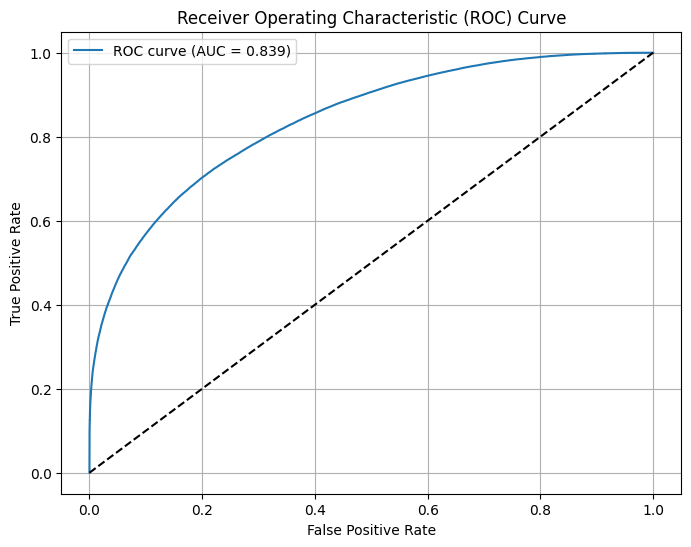

In [7]:
epochs = 500
patience = 5  # epochs to wait for improvement
min_delta = 1e-4  # minimum change to qualify as improvement
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb, yb_reg in train_loader:
        
        xb = xb.to(device)
        yb = yb.to(device).flatten()
        yb_reg = yb_reg.to(device).flatten()

        optimizer.zero_grad()    
        logits = model(xb)
        loss = criterion(logits[:, 0], yb)
        reg_loss = criterion_regression(logits[:, 1], yb_reg)
        total_loss = (1 * loss) + (1 * reg_loss)
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    if epoch % 5 == 0 or epoch == 1:
        with torch.no_grad():
            logits = model(torch.from_numpy(X_train).to(device))
            preds = (torch.sigmoid(logits[:, 0]).cpu().numpy().ravel() >= 0.5).astype(int)
            acc = (preds == y_train).mean() if len(y_train) else float('nan')
            mae = torch.mean(torch.abs(logits[:, 1].cpu() - torch.from_numpy(y_reg_train))).item()
            corr = np.corrcoef(logits[:, 1].detach().cpu().numpy().ravel(), y_reg_train)[0, 1]

        print(f'\nEpoch {epoch:03d} | Loss = {epoch_loss:.4f} | Train_acc = {acc:.3f} | Train_MAE = {mae:.4f} | Train_Corr = {corr:.3f}')

    
# 7) Evaluate on test set
model.eval()
with torch.no_grad():
    logits = model(torch.from_numpy(X_test).to(device))
    probs = torch.sigmoid(logits[:, 0]).cpu().numpy().ravel()
    y_pred = (probs >= 0.5).astype(int)
    y_reg_pred = logits[:, 1].cpu().numpy().ravel()
test_acc = (y_pred == y_test).mean() if len(y_test) else float('nan')
reg_test_mae = torch.mean(torch.abs(torch.tensor(y_reg_pred) - torch.tensor(y_reg_test))).item() if len(y_reg_test) else float('nan')
print(f'Test regression MAE: {reg_test_mae:.4f}')
print(f'Test accuracy: {test_acc:.3f}  (n_test={len(y_test)})')

# Precision, Recall, F1
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
print(f'Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}')

roc_auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()

torch.save(model.state_dict(), os.path.join(cache_path, 'alpaca_multi_model_calendar_spread_v6.pth'))


In [49]:
torch.save(model.state_dict(), os.path.join(cache_path, 'alpaca_multi_model_calendar_spread_v6.pth'))


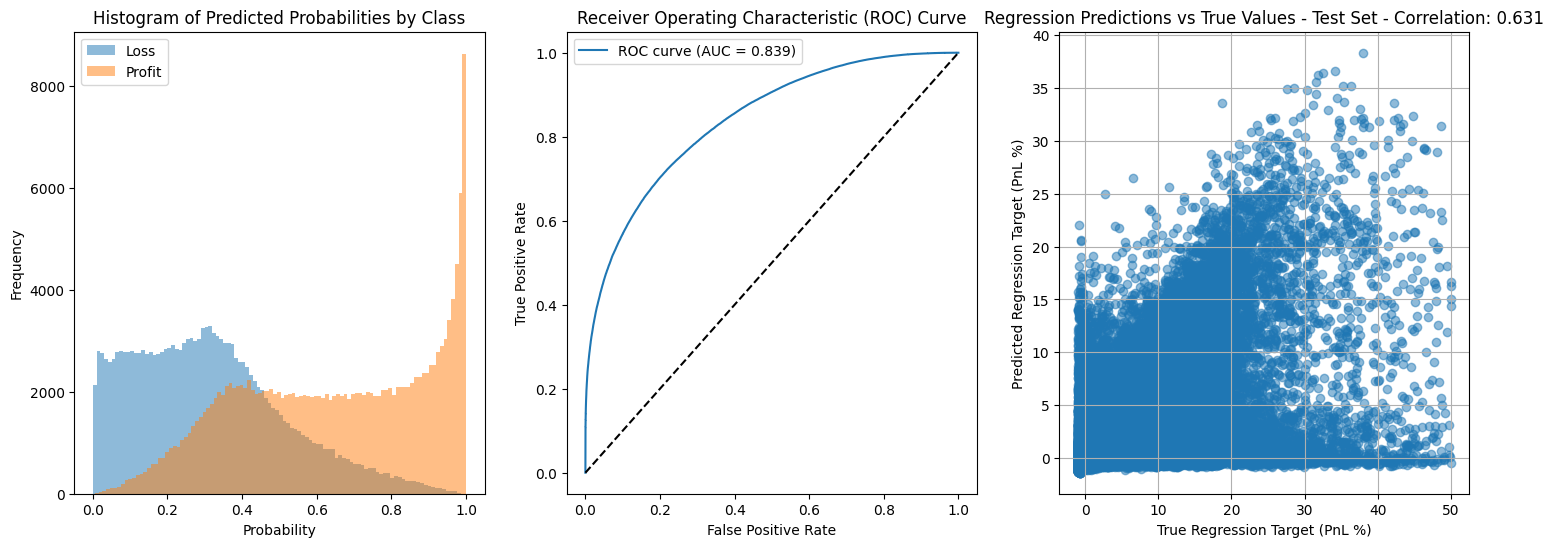

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
axs[0].hist(probs[np.where(y_test == 0)[0]], bins=100, alpha=0.5, label='Loss')
axs[0].hist(probs[np.where(y_test == 1)[0]], bins=100, alpha=0.5, label='Profit')
axs[0].set_xlabel('Probability')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Histogram of Predicted Probabilities by Class')
axs[0].legend()

axs[1].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
axs[1].plot([0, 1], [0, 1], 'k--')
axs[1].set_xlabel('False Positive Rate')
axs[1].set_ylabel('True Positive Rate')
axs[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axs[1].legend()

axs[2].scatter(invert_reg_scale(y_reg_test, std_reg_scale, mean_reg_scale), invert_reg_scale(y_reg_pred, std_reg_scale, mean_reg_scale), alpha=0.5)
axs[2].set_xlabel('True Regression Target (PnL %)')
axs[2].set_ylabel('Predicted Regression Target (PnL %)')
axs[2].set_title(f'Regression Predictions vs True Values - Test Set - Correlation: {np.corrcoef(y_reg_test, y_reg_pred)[0, 1]:.3f}')
axs[2].grid()
plt.show()

81.04599293204804

In [11]:
data['Symbol'] = data['Trade_ID'].apply(lambda x: x.split('|')[1][:4])

/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_28601/422467660.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols + ['PnL Percent', 'Symbol'])


Per-symbol ROC AUC (NaN = not computable due to single class):


,Symbol,n,pos_rate,roc_auc
0,NFLX,90005,0.487906,0.802818
1,NVDA,143256,0.445035,0.771839
2,TSLA,150650,0.497617,0.761071
3,GLD2,289883,0.498587,0.749441
4,META,159818,0.529358,0.740134
5,CRWV,21391,0.562480,0.734244
6,AAPL,81307,0.433554,0.723936
7,GOOG,65791,0.419404,0.722997
8,MSFT,126643,0.445109,0.691426
9,SMR2,26746,0.582779,0.688822



Per-symbol + Option Type ROC AUC (NaN = not computable due to single class):


,Symbol,OptionType,n,pos_rate,roc_auc
0,AAPL,call,34276,0.477710,0.761883
1,AAPL,put,47031,0.401374,0.685289
2,AMZN,call,28945,0.571981,0.718137
3,AMZN,put,44562,0.418810,0.631360
4,CAT2,call,15026,0.571809,0.645136
5,CAT2,put,22098,0.452620,0.621180
6,CEG2,call,7261,0.649084,0.465680
7,CEG2,put,8970,0.567336,0.542115
8,CRWV,call,11110,0.528533,0.677513
9,CRWV,put,10281,0.599164,0.799908


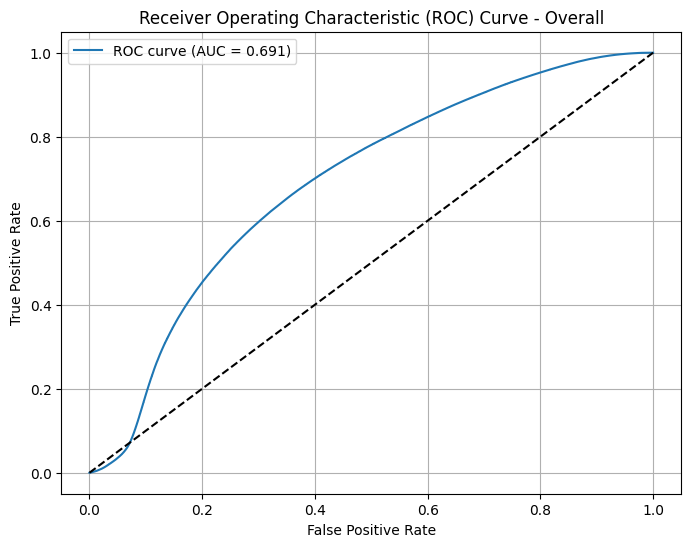

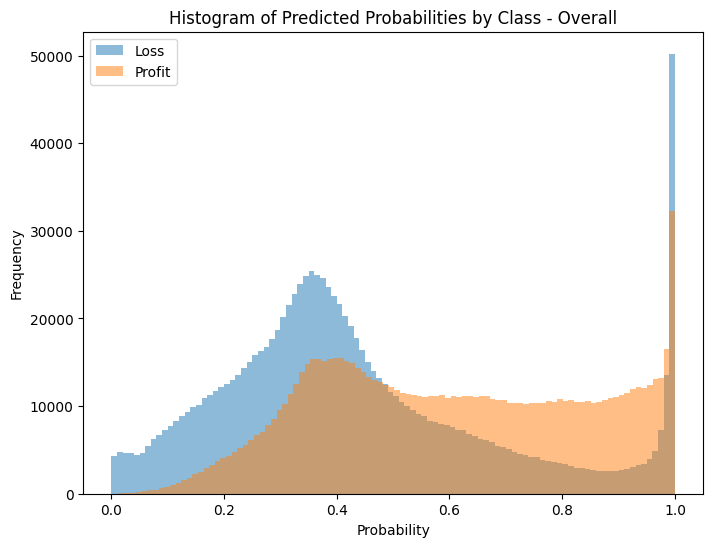

In [12]:
# Test set 

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model_path='/Users/zohairshafi/Local Workspace/spectral_nature/cache'
model_name='alpaca_multi_model_calendar_spread_v3.pth'
params_name='alpaca_multi_model_calendar_spread_params_v3.pkl'

model = OptionModel(in_dim = len(feature_cols)).to(device)
model.load_state_dict(torch.load(os.path.join(model_path, model_name), map_location=device))
with open(os.path.join(model_path, params_name), 'rb') as file: 
    model_params = pkl.load(file)

min_x_train = model_params['min_x_train']
ptp_x_scale = model_params['ptp_x_scale']
min_reg_scale = model_params['min_reg_scale']
denom_reg_scale = model_params['denom_reg_scale']
feature_cols = model_params['feature_cols']

model.eval()

# Build modeling frame for inference including Symbol, Option Type, and PnL for per-symbol metrics
df_model = data[feature_cols + ['PnL Percent', 'Symbol']].copy()

# Clean and standardize
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols + ['PnL Percent', 'Symbol'])
X_options = df_model[feature_cols].to_numpy(dtype=np.float32)
X_options = (X_options - min_x_train) / ptp_x_scale

# Inference
logits = model(torch.from_numpy(X_options).to(device))
probs = torch.sigmoid(logits[:, 0]).detach().cpu().numpy().ravel()
y_reg_pred = logits[:, 1].detach().cpu().numpy().ravel()
y_reg_pred_original = invert_reg_scale(y_reg_pred, denom_reg_scale, min_reg_scale)

# Overall metrics
df_model['prob'] = probs
df_model['label'] = (df_model['PnL Percent'] > 0).astype(int)
y_overall = df_model['label'].to_numpy()

# Handle degenerate case where only one class exists overall
roc_auc = np.nan
if len(np.unique(y_overall)) > 1:
    roc_auc = roc_auc_score(y_overall, probs)
    fpr, tpr, _ = roc_curve(y_overall, probs)
else:
    fpr, tpr = np.array([0, 1]), np.array([0, 1])

# Per-symbol AUC characteristics
rows = []
for sym, grp in df_model.groupby('Symbol'):
    y_sym = grp['label'].to_numpy()
    p_sym = grp['prob'].to_numpy()
    if len(np.unique(y_sym)) < 2:
        sym_auc = np.nan  # cannot compute ROC AUC with single class
    else:
        sym_auc = roc_auc_score(y_sym, p_sym)
    rows.append({
        'Symbol': sym,
        'n': int(len(grp)),
        'pos_rate': float(y_sym.mean()) if len(y_sym) else np.nan,
        'roc_auc': float(sym_auc) if sym_auc == sym_auc else np.nan  # keep NaN if not computable
    })
auc_by_symbol = pd.DataFrame(rows).sort_values(['roc_auc', 'n'], ascending=[False, False])

# Per-symbol & option type AUC characteristics (Option Type may be part of feature_cols)
# If Option Type exists in df_model columns proceed; else skip gracefully
if 'Option Type' in df_model.columns:
    rows_opt = []
    # Map numeric to string for readability
    type_map = {1: 'call', 0: 'put'}
    for (sym, opt_type), grp in df_model.groupby(['Symbol', 'Option Type']):
        y_grp = grp['label'].to_numpy()
        p_grp = grp['prob'].to_numpy()
        if len(np.unique(y_grp)) < 2:
            grp_auc = np.nan
        else:
            grp_auc = roc_auc_score(y_grp, p_grp)
        rows_opt.append({
            'Symbol': sym,
            'OptionTypeRaw': int(opt_type),
            'OptionType': type_map.get(int(opt_type), str(opt_type)),
            'n': int(len(grp)),
            'pos_rate': float(y_grp.mean()) if len(y_grp) else np.nan,
            'roc_auc': float(grp_auc) if grp_auc == grp_auc else np.nan
        })
    auc_by_symbol_option = pd.DataFrame(rows_opt).sort_values(['roc_auc', 'n'], ascending=[False, False])
else:
    auc_by_symbol_option = pd.DataFrame(columns=['Symbol','OptionType','n','pos_rate','roc_auc'])

# Display per-symbol table
print('Per-symbol ROC AUC (NaN = not computable due to single class):')
display(auc_by_symbol.reset_index(drop=True))

print('\nPer-symbol + Option Type ROC AUC (NaN = not computable due to single class):')
auc_by_symbol_option = auc_by_symbol_option.drop(columns=['OptionTypeRaw'])
auc_by_symbol_option.sort_values(['Symbol', 'OptionType'], inplace=True)
display(auc_by_symbol_option.reset_index(drop=True))

# Existing overall visualizations
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})' if roc_auc == roc_auc else 'ROC curve (AUC = N/A)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Overall')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(df_model.loc[y_overall == 0, 'prob'], bins=100, alpha=0.5, label='Loss')
plt.hist(df_model.loc[y_overall == 1, 'prob'], bins=100, alpha=0.5, label='Profit')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted Probabilities by Class - Overall')
plt.legend()
plt.show()

# Live Data Tests

In [9]:
symbol = 'NVDA'

########################################
####### Get options information ########
########################################
option_details, strike_group, current_price = get_options_information(symbol = symbol,
                                                                       start_day_offset = 10,
                                                                       end_day_offset = 150,
                                                                       option_type = 'call',
                                                                       percentage_to_search = 0.3,
                                                                       headers = headers)
display(option_details)

########################################
####### Filter Possible Trades #########
########################################
o = filter_option_trades_by_ff(strike_group = strike_group,
                           current_price = current_price,
                           min_time_distance = 5,
                           max_time_distance = 120,
                           min_ff_perc = 1, 
                           max_ff_perc = 50, 
                           print_output = False)

list_of_options = []
for idx, options_df in enumerate(o):

    conf, reg_pred = get_model_confidence(underlying_price = current_price,
                                          options_df = options_df, 
                                          model_name='alpaca_multi_model_calendar_spread_v6.pth',
                                          params_name='alpaca_multi_model_calendar_spread_params_v6.pkl',
                                          model_dims=512)
    list_of_options.append((conf, reg_pred, options_df))

sorted_options = sorted(list_of_options, key=lambda x: x[0][0], reverse=True)

print_idx = 0
for conf, reg_pred, options_df in sorted_options:
    print(f"Profit Probability: {conf[0] * 100:0.3f}%\nModel Regression Predictions: {reg_pred[0] * 100:0.3f}%")
    display(options_df)
    print_idx += 1
    if print_idx >= 15:
        break


Symbol | NVDA
Current Price: 182.45 (Time : 2025-12-05T15:50:00Z)


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price
0,NVDA251219C00182500,2025-12-19,182.5,6.45,call,0.5172,0.0273,0.0339,-0.2168,0.1423,0.4083,5.86,5.81
1,NVDA251219C00183000,2025-12-19,183,6.25,call,0.5026,0.0283,0.0331,-0.2099,0.1424,0.3949,5.46,5.35
2,NVDA260116C00183000,2026-01-16,183,10.65,call,0.5282,0.016,0.0994,-0.1265,0.246,0.4012,9.94,9.9
3,NVDA251219C00184000,2025-12-19,184,5.7,call,0.4757,0.0276,0.0313,-0.2136,0.1422,0.4038,5.1,5.05
4,NVDA260116C00184000,2026-01-16,184,10.04,call,0.5121,0.0161,0.0966,-0.1261,0.2465,0.3999,9.45,9.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,NVDA251226C00235000,2025-12-26,235,0.1,call,0.0149,0.0018,0.0015,-0.0188,0.0165,0.4711,0.11,0.1
136,NVDA260102C00235000,2026-01-02,235,0.18,call,0.0217,0.0024,0.0029,-0.0208,0.0262,0.4358,0.2,0.14
137,NVDA260109C00235000,2026-01-09,235,0.32,call,0.0329,0.0031,0.0055,-0.0257,0.0414,0.4243,0.32,0.27
138,NVDA260116C00235000,2026-01-16,235,0.53,call,0.0466,0.0037,0.0092,-0.031,0.0602,0.4206,0.5,0.45


Profit Probability: 57.942%
Model Regression Predictions: 12.797%


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,NVDA251219C00184000,2025-12-19,184,5.7,call,0.4757,0.0276,0.0313,-0.2136,0.1422,0.4038,5.10,5.05,1.43784,-4.4
1,NVDA260116C00184000,2026-01-16,184,10.04,call,0.5121,0.0161,0.0966,-0.1261,0.2465,0.3999,9.45,9.40,1.43784,-4.4


Profit Probability: 53.164%
Model Regression Predictions: 14.275%


...

,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,NVDA260320C00195000,2026-03-20,195,13.36,call,0.4519,0.0092,0.1999,-0.0886,0.3872,0.4422,12.91,12.86,9.287965,-2.18
1,NVDA260417C00195000,2026-04-17,195,15.44,call,0.4702,0.0083,0.2580,-0.0787,0.4377,0.4345,15.04,14.75,9.287965,-2.18


Profit Probability: 7.321%
Model Regression Predictions: 8.025%


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,NVDA260116C00195000,2026-01-16,195,5.5,call,0.3405,0.0152,0.0656,-0.1112,0.2267,0.3900,5.12,5.07,9.161217,-0.7
1,NVDA260123C00195000,2026-01-23,195,6.2,call,0.3551,0.0145,0.0792,-0.1039,0.2487,0.3854,5.77,5.70,9.161217,-0.7


Profit Probability: 3.379%
Model Regression Predictions: 25.398%


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,NVDA251219C00200000,2025-12-19,200,1.01,call,0.1236,0.0147,0.0083,-0.1039,0.0729,0.3901,0.85,0.8,2.235103,-3.58
1,NVDA260123C00200000,2026-01-23,200,4.71,call,0.2900,0.0134,0.0651,-0.0946,0.2286,0.3839,4.38,4.3,2.235103,-3.58


Epoch 100 Loss: 14.988
Epoch 200 Loss: 7.408
Epoch 300 Loss: 4.788
Epoch 400 Loss: 3.479
Epoch 500 Loss: 2.715
Epoch 600 Loss: 2.222
Epoch 700 Loss: 1.880
Epoch 800 Loss: 1.630
Epoch 900 Loss: 1.440
Epoch 1000 Loss: 1.289
Epoch 1100 Loss: 1.168
Epoch 1200 Loss: 1.067
Epoch 1300 Loss: 0.982
Epoch 1400 Loss: 0.909
Epoch 1500 Loss: 0.845
Epoch 1600 Loss: 0.790
Epoch 1700 Loss: 0.740
Epoch 1800 Loss: 0.696
Epoch 1900 Loss: 0.656
Epoch 2000 Loss: 0.620
Epoch 2100 Loss: 0.587
Epoch 2200 Loss: 0.557
Epoch 2300 Loss: 0.529
Epoch 2400 Loss: 0.504
Epoch 2500 Loss: 0.480
Epoch 2600 Loss: 0.458
Epoch 2700 Loss: 0.437
Epoch 2800 Loss: 0.417
Epoch 2900 Loss: 0.399
Epoch 3000 Loss: 0.382
Epoch 3100 Loss: 0.366
Epoch 3200 Loss: 0.351
Epoch 3300 Loss: 0.336
Epoch 3400 Loss: 0.322
Epoch 3500 Loss: 0.309
Epoch 3600 Loss: 0.297
Epoch 3700 Loss: 0.285
Epoch 3800 Loss: 0.274
Epoch 3900 Loss: 0.264
Epoch 4000 Loss: 0.254
Epoch 4100 Loss: 0.244
Epoch 4200 Loss: 0.235
Epoch 4300 Loss: 0.226
Epoch 4400 Loss: 0.

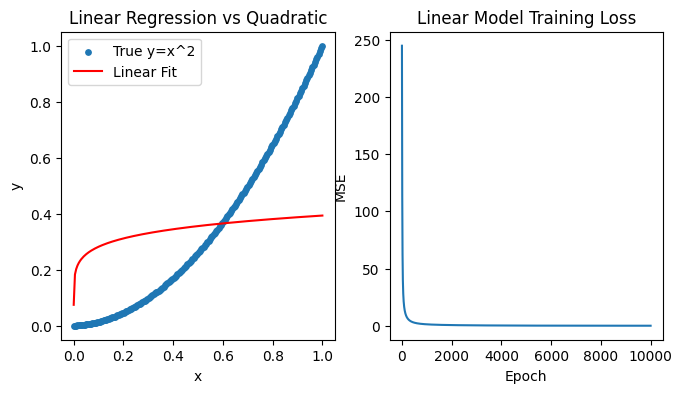

In [9]:
# Simple linear regression attempting to learn y = x**2
# Demonstrates limitation of a purely linear model and an optional fix with polynomial features.

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Wrap the linear model in a simple PyTorch class
class SimpleLinearRegressor(nn.Module):
    def __init__(self, in_features=1, hidden_features=4, out_features=1):
        super().__init__()
        self.linear = nn.Linear(in_features, hidden_features)
        self.output = nn.Linear(hidden_features, out_features)

        self.branch_linear = nn.Linear(in_features, hidden_features)
        self.branch_output = nn.Linear(hidden_features, out_features)

    def forward(self, in_x):

        x = torch.log(in_x)
        x = self.linear(x)
        x = torch.exp(x) + 1e-9  # avoid zero

        x = torch.log(x)
        x = self.output(x)
        x = torch.exp(x) + 1e-9  # avoid zero

        o = self.branch_linear(in_x)
        o = nn.ReLU()(o)
        o = self.branch_output(o)
        o = nn.Sigmoid()(o)
        
        return x + o


# 1. Generate data
n = 200
x = torch.linspace(1.0, 50.0, n).unsqueeze(1)  # shape [n,1]
y_true = x**2  # quadratic target

# Normalize 
x = (x - x.min()) / (x.max() - x.min())
x += 1e-5  # avoid zero

# x =torch.hstack([x, x])

y_true = (y_true - y_true.min()) / (y_true.max() - y_true.min())
y_true += 1e-5  # avoid zero

# 2. Define a simple linear regression model via the class (cannot represent x**2 well)
linear_model = SimpleLinearRegressor()

# 3. Train the linear model
optimizer = torch.optim.Adam(linear_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 10000
loss_history_linear = []
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    y_pred = linear_model(x)
    loss = criterion(y_pred, y_true)
    loss.backward()
    optimizer.step()
    loss_history_linear.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} Loss: {loss.item():.3f}")

# 4. Evaluate linear fit
with torch.no_grad():
    y_linear = linear_model(x)

# 5. Plot linear results
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(x.numpy()[:, 0], y_true.numpy(), s=15, label='True y=x^2')
plt.plot(x.numpy()[:, 0], y_linear.numpy(), color='red', label='Linear Fit')
plt.title('Linear Regression vs Quadratic')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1,3,2)
plt.plot(loss_history_linear)
plt.title('Linear Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()


In [3]:
# Fetch open multi-leg option strategies and compute entry vs current
import os, json, re, math
import requests
import pandas as pd
import numpy as np
from datetime import datetime

# --- Config: set your API keys via environment variables or inline ---

BASE_URL =  'https://api.alpaca.markets'
DATA_URL = 'https://data.alpaca.markets'


# --- Helpers ---
option_multiplier = 100

def parse_option_symbol(sym: str):
    """Parse Alpaca option symbol like SPY250616P00571000 -> (underlying, expiry, type, strike)"""
    try:
        underlying = re.match(r'^([A-Z\.]+)\d{6}[CP]\d{8}$', sym).group(1)
        yymmdd = sym[len(underlying):len(underlying)+6]
        opt_type = 'put' if sym[len(underlying)+6] == 'P' else 'call'
        strike = float(sym[-8:]) / 1000.0
        expiry = pd.to_datetime(yymmdd, format='%y%m%d', utc=True)
        return underlying, expiry, opt_type, strike
    except Exception:
        return None, None, None, None

def fetch_open_option_positions():
    url = f"{BASE_URL}/v2/positions"
    resp = requests.get(url, headers=headers)
    pos = json.loads(resp.text)
    # Some SDKs return dict; normalize to list
    if isinstance(pos, dict):
        pos = pos.get('positions', [])
    return [p for p in pos if p.get('asset_class') == 'us_option']

def batch_snapshots(symbols: list[str]) -> dict:
    """Fetch latest bid/ask for each option symbol and return mid prices."""
    prices = {}
    if not symbols:
        return prices
    for chunk in np.array_split(symbols, 1 + (len(symbols) // 100)):
        syms = ','.join(chunk)
        url = f"{DATA_URL}/v1beta1/options/snapshots?symbols={syms}&feed=indicative&limit=100"
        r = requests.get(url, headers=headers)
        data = json.loads(r.text)
        for sym, snap in data.get('snapshots', {}).items():
            q = snap.get('latestQuote', {})
            ap = q.get('ap')
            bp = q.get('bp')
            if ap is not None and bp is not None and ap > 0 and bp > 0:
                prices[sym] = (ap + bp) / 2.0
    return prices

# --- Load positions and group into strategies ---
positions = fetch_open_option_positions()
if len(positions) == 0:
    display(pd.DataFrame(columns=['Underlying','Type','Strike','Legs','Net Entry ($)', 'Net Current ($)', 'PnL ($)', 'PnL (%)']))
else:
    df = pd.DataFrame([{
        'symbol': p.get('symbol'),
        'qty': float(p.get('qty', 0)),
        'side': p.get('side'),  # 'long' or 'short'
        'avg_entry_price': float(p.get('avg_entry_price', 0)),
    } for p in positions])

    # Parse symbols
    parsed = df['symbol'].apply(parse_option_symbol)
    df[['underlying','expiry','type','strike']] = pd.DataFrame(parsed.tolist(), index=df.index)

    # Filter rows with valid parse
    df = df.dropna(subset=['underlying','type','strike'])

    # Strategy key: same underlying + strike + type (calendar spreads etc.)
    df['strategy_key'] = df.apply(lambda r: f"{r['underlying']}_{r['type']}_{r['strike']}", axis=1)

    # Compute leg entry value with sign (buy = debit, sell = credit negative)
    df['leg_entry_value'] = np.where(df['side'].str.lower().isin(['long','buy']),
                                     df['avg_entry_price'] * df['qty'] * option_multiplier,
                                     -df['avg_entry_price'] * df['qty'] * option_multiplier)
    
    # Fix leg entry value for multiple contracts
    df['leg_entry_value'] = df['leg_entry_value'] * df['qty']

    # Fetch current mid prices
    snap_prices = batch_snapshots(df['symbol'].unique().tolist())
    df['current_mid'] = df['symbol'].map(snap_prices)

    # Compute leg current value with sign (long positive, short negative)
    df['leg_current_value'] = np.where(df['side'].str.lower().isin(['long','buy']),
                                       df['current_mid'] * df['qty'] * option_multiplier,
                                       -df['current_mid'] * df['qty'] * option_multiplier)
    # Fix leg current value for multiple contracts
    df['leg_current_value'] = df['leg_current_value'] * df['qty']


    # Aggregate per strategy
    strat = df.groupby('strategy_key').agg({
        'underlying':'first',
        'type':'first',
        'strike':'first',
        'symbol':'count',
        'leg_entry_value':'sum',
        'leg_current_value':'sum',
    }).rename(columns={'symbol':'legs'})

    strat['pnl_abs'] = strat['leg_current_value'] - strat['leg_entry_value']
    strat['pnl_pct'] = np.where(strat['leg_entry_value'] != 0,
                                100.0 * strat['pnl_abs'] / np.abs(strat['leg_entry_value']),
                                np.nan)
    strat['pnl_pct'] = strat['pnl_pct'].round(2)

    strat = strat.reset_index(drop=True)
    strat = strat.sort_values(by=['underlying','type','strike'])

    strat.rename(columns={
        'underlying':'Underlying',
        'type':'Type',
        'strike':'Strike',
        'legs':'Legs',
        'leg_entry_value':'Net Entry ($)',
        'leg_current_value':'Net Current ($)',
        'pnl_abs':'PnL ($)',
        'pnl_pct':'PnL (%)',
    }, inplace=True)

    display(strat)


,Underlying,Type,Strike,Legs,Net Entry ($),Net Current ($),PnL ($),PnL (%)
0,EQX,call,12.5,2,35.0,28.5,-6.5,-18.57
1,QCOM,call,180.0,2,277.0,549.0,272.0,98.19


# Combinatorcs

In [2]:

def compute_historical_sigma(symbol: str,
                              timeframe: str,
                              historical_start_date: str,
                              historical_end_date: str = 'now',
                              headers: dict | None = None,
                              method: str = 'log',
                              trading_days: int = 252,
                              window: int | None = None) -> tuple[float, pd.Series]:
    """
    Compute annualized volatility (sigma) from historical prices fetched via get_historical_stock_price.

    Args:
        symbol: Ticker symbol (e.g., 'SPY')
        timeframe: Alpaca timeframe (e.g., '1D', '1H')
        historical_start_date: ISO date string, e.g., '2024-01-01'
        historical_end_date: ISO date string or 'now'
        headers: API headers
        method: 'log' (default) for log returns, 'simple' for simple returns
        trading_days: Number of periods per year (252 for daily)
        window: Optional rolling window length to compute recent sigma; if None, use full period

    Returns:
        (annualized_sigma, returns_series)
    """
    c, _, _, t = get_historical_stock_price(symbol, timeframe, historical_start_date, historical_end_date, headers)
    # Ensure chronological order (API is ascending; safeguard anyway)
    order = np.argsort(t)
    prices = c[order].astype(float)

    if method == 'simple':
        rets = pd.Series(prices[1:] / prices[:-1] - 1.0)
    else:
        rets = pd.Series(np.log(prices[1:] / prices[:-1]))

    if window is not None and window > 1:
        # Use last "window" returns for sigma
        rets_used = rets.tail(window)
    else:
        rets_used = rets

    # Handle edge cases
    if len(rets_used) < 2:
        return 0.0, rets

    # Annualize: sigma = std(Returns) * sqrt(periods_per_year)
    periods_per_year = trading_days
    sigma_annual = float(rets_used.std(ddof=1) * np.sqrt(periods_per_year))

    return sigma_annual, rets, prices[-1]


In [ ]:
class BlackScholes(nn.Module):
    def __init__(self, option_type):
        '''
            option_type: 'call' or 'put'
        '''
        super().__init__()
        self.option_type = option_type

    def forward(self, x):
        """Calculate Black-Scholes option price.

        Args:
            S: Current stock price
            K: Strike price
            T: Time to expiration in years
            r: Risk-free interest rate (annualized)
            sigma: Volatility of underlying (annualized)
            q: continuous dividend yield (decimal, default 0.0)

        Returns:
            Option price
        """

        try:
            S, K, T, r, sigma, q = x[:, 0], x[:, 1], x[:, 2], x[:, 3], x[:, 4], x[:, 5]
        except:
            S, K, T, r, sigma, q = x[0], x[1], x[2], x[3], x[4], x[5]

        # mask of rows where we want to fall back to intrinsic value
        invalid = (T <= 0) | (sigma <= 0) | (S <= 0) | (K <= 0)

        # intrinsic values (vector)
        intrinsic_call = torch.clamp(S - K, min=0.0)
        intrinsic_put  = torch.clamp(K - S, min=0.0)

        d1 = (torch.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * torch.sqrt(T) + 1e-9)
        d2 = d1 - sigma * torch.sqrt(T)

        N = torch.distributions.Normal(0, 1).cdf

        if self.option_type == 'call':
            price = S *  torch.exp(-q * T) * N(d1) - K * torch.exp(-r * T) * N(d2)
            price = torch.where(invalid, intrinsic_call, price)
        else:  # put
            price = K * torch.exp(-r * T) * N(-d2) - S * torch.exp(-q * T) * N(-d1)
            price = torch.where(invalid, intrinsic_put, price)

        return price
    
class StrategyFinder(nn.Module):

    def __init__(self, current_price, sigma, option_type, short_strike_init, long_strike_init, short_dte_init=20, long_dte_init=200):
        super().__init__()

        self.current_price = current_price
        self.option_type = option_type
        self.risk_free_rate = 0.04  # 4% annualized
        self.sigma = sigma  # 60% annualized
        self.dividend_yield = 0.0  # assume zero dividend yield
        
        self.bs_model_short = BlackScholes(option_type)
        self.bs_model_long = BlackScholes(option_type)

        # Learn the optimal short strike
        self.short_strike = torch.nn.Parameter(torch.FloatTensor([short_strike_init]), requires_grad=True)

        # Learn the optimal long strike
        self.long_strike = torch.nn.Parameter(torch.FloatTensor([long_strike_init]), requires_grad=True)

        # Learn the optimal short dte
        self.short_dte = torch.nn.Parameter(torch.FloatTensor([short_dte_init]), requires_grad=True)
        
        # Learn the optimal long dte
        self.long_dte = torch.nn.Parameter(torch.FloatTensor([long_dte_init]), requires_grad=True)

        self.pnl_dict = {}

    def get_bs_input(self, dte, current, strike, r, sigma, q = 0.0):

        steps = int(dte)
        dtes = torch.arange(steps, 0, -1, dtype=torch.float32)
        T = dtes / 365.0

        S = torch.full_like(T, float(current))
        if isinstance(strike, torch.Tensor):
            K = strike.expand_as(T)
        else:
            K = torch.full_like(T, float(strike))

        R = torch.full_like(T, float(r))
        Sigma = torch.full_like(T, float(sigma))
        Q = torch.full_like(T, float(q))

        bs_input = torch.stack([S, K, T, R, Sigma, Q], dim=1)
        return bs_input

    def forward(self):

        # Clear previous graph-dependent state
        self.pnl_dict = {}

        # Compute short prices
        short_input = self.get_bs_input(dte = self.short_dte,
                                    current = self.current_price,
                                    strike = self.short_strike,
                                    r = self.risk_free_rate,
                                    sigma = self.sigma,
                                    q = self.dividend_yield)
        self.entry_short_prices = self.bs_model_short(short_input)

        # Compute long prices 
        long_input = self.get_bs_input(dte = self.long_dte,
                                    current = self.current_price,
                                    strike = self.long_strike,
                                    r = self.risk_free_rate,
                                    sigma = self.sigma,
                                    q = self.dividend_yield)
        self.entry_long_prices = self.bs_model_long(long_input)


        # Compute difference in prices as profit 
        min_range = min(self.current_price, self.short_strike, self.long_strike)
        max_range = max(self.current_price, self.short_strike, self.long_strike)

        r = get_risk_free_rate_estimate(self.long_dte.item())
        sweep_range = range(int(min_range - (0.25 * min_range)),
                            int(max_range + (0.25 * max_range)),
                            1)

        self.entry_debit = self.entry_long_prices[0] - self.entry_short_prices[0]

        # Remaining DTE for the long leg when the short expires
        remaining_dte = int(self.long_dte - self.short_dte)
        
        for current in sweep_range:

            # Value of long leg at short expiry given current underlying
            long_price_input = self.get_bs_input(dte = self.long_dte,
                                    current = current,
                                    strike = self.long_strike,
                                    r = self.risk_free_rate,
                                    sigma = self.sigma,
                                    q = self.dividend_yield)
            long_price_dict = self.bs_model_long(long_price_input)
            
            long_value_at_short_expiry = long_price_dict[int(self.long_dte.item()) - remaining_dte]

            # Short leg expires: cash settlement equals intrinsic value at expiry
            current_t = torch.tensor(float(current), device=self.short_strike.device)
            short_intrinsic = torch.clamp(current_t - self.short_strike, min=0.0)

            # PnL: value of long at short expiry minus cost to settle short and initial net debit
            pnl = long_value_at_short_expiry - short_intrinsic - self.entry_debit
            self.pnl_dict[int(current)] = 100 * pnl / self.entry_debit  # PnL %

        # Return area under curve for profit
        pnl_values = torch.stack([v.reshape(()) for v in self.pnl_dict.values()])
        pos_values = torch.clamp(pnl_values, min=0.0)
        neg_values = torch.clamp(pnl_values, max=0.0)
        pos_auc = torch.trapz(pos_values, dx=1.0)
        neg_auc = torch.trapz(torch.abs(neg_values), dx=1.0) + 1e-9  # avoid zero

        return pos_auc, neg_auc
    
    def plot_pnl(self):

        y = [x.item() for x in self.pnl_dict.values()]
        plt.plot(self.pnl_dict.keys(), y)
        plt.xlabel('Underlying Price at Short Leg Expiration ($)')
        plt.ylabel('Calendar Spread PnL (%)')
        plt.title(f'Calendar Spread PnL vs Underlying Price (Short K={int(self.short_strike.item())}, Long K={int(self.long_strike.item())})\nCost=${self.entry_debit.item():.2f} | Profit at Long K={self.pnl_dict[int(self.long_strike.item())].item():.3f}%')
        plt.grid()
        plt.axhline(0, color='black', linestyle='--')
        plt.axvline(self.current_price, color = 'red', linestyle = '--', label = 'Current Price')
        plt.axvline(int(self.long_strike.item()), color = 'green', linestyle = '--', label = 'Long Strike')
        plt.legend()
        plt.show()

In [146]:
BS = BlackScholes('call')
BS(torch.Tensor(long_mat).T[0:5, :])

tensor([12.6788, 12.5753, 12.4713, 12.3668, 12.2618])

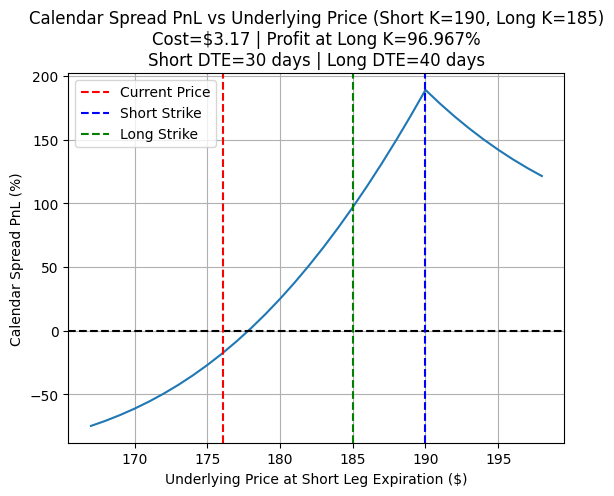

Epoch 010 Loss: -4.849 | Pos AUC: 2269.707 | Neg AUC: 468.107
Epoch 020 Loss: -4.967 | Pos AUC: 2296.260 | Neg AUC: 462.318
Epoch 030 Loss: -5.097 | Pos AUC: 2324.708 | Neg AUC: 456.099
Epoch 040 Loss: -5.243 | Pos AUC: 2355.619 | Neg AUC: 449.330


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [28]:
symbol = 'NVDA'
sigma, _, current_price = compute_historical_sigma(symbol, '1D', '2025-01-01', headers=headers)

short_strike = 190
short_dte = 30

long_strike = 185
long_dte = 40

SF = StrategyFinder(current_price=current_price,
                        sigma=sigma,
                        option_type='call',
                        short_strike_init=short_strike,
                        long_strike_init=long_strike,
                        short_dte_init=short_dte,
                        long_dte_init=long_dte)
pos_auc, neg_auc = SF()
SF.plot_pnl()


SF.train()
optimizer = torch.optim.Adam(SF.parameters(), lr=1e-2)
epochs = 500
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    pos_auc, neg_auc = SF()
    loss = - (pos_auc / neg_auc)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} Loss: {loss.item():.3f} | Pos AUC: {pos_auc.item():.3f} | Neg AUC: {neg_auc.item():.3f}")

SF.plot_pnl()

(tensor(5156.2065), tensor(3831.5164))

In [219]:
SF.entry_short_prices


tensor([5.1790e+00, 5.0182e+00, 4.8555e+00, 4.6909e+00, 4.5242e+00, 4.3555e+00,
        4.1847e+00, 4.0116e+00, 3.8362e+00, 3.6585e+00, 3.4783e+00, 3.2957e+00,
        3.1104e+00, 2.9226e+00, 2.7320e+00, 2.5388e+00, 2.3429e+00, 2.1442e+00,
        1.9431e+00, 1.7395e+00, 1.5339e+00, 1.3269e+00, 1.1192e+00, 9.1238e-01,
        7.0868e-01, 5.1193e-01, 3.2850e-01, 1.6937e-01, 5.3039e-02, 2.8098e-03])

In [101]:
# Option pricing helpers

import numpy as np

from scipy.stats import norm

"""
Black–Scholes (European option pricing)
Parameters:
- S: current underlying price
- K: strike price
- T: time to expiration in years (e.g., 30 days -> 30/365)
- r: annual risk-free rate (decimal, e.g., 0.04)
- sigma: annualized volatility of underlying (decimal, e.g., 0.25 for 25%)
- q: continuous dividend yield (decimal, default 0.0)
- option_type: 'call' or 'put'
Returns:
- European option price in dollars
"""



def black_scholes_price(S: float, K: float, T: float, r: float, sigma: float, option_type: str = 'call', q: float = 0.0) -> float:

    # Boundary conditions (avoid division by zero; approximate by intrinsic value)
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        if option_type.lower() == 'call':
            return float(max(0.0, S - K))
        else:
            return float(max(0.0, K - S))

    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT

    if option_type.lower() == 'call':
        price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:  # put
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    return float(price)


def american_option_price(S: float,
                          K: float,
                          T: float,
                          r: float,
                          sigma: float,
                          option_type: str = 'call',
                          q: float = 0.0,
                          steps: int = 200) -> float:
    
    """
    Cox–Ross–Rubinstein binomial tree (American option pricing)

    This model allows for early exercise and should be used for
    American-style equity options (the typical US listed stock options).
    Parameters:
    - S, K, T, r, sigma, q, option_type: same as above
    - steps: number of binomial steps in the tree (higher = more accurate)
    Returns:
    - American option price in dollars
    """
    option_type = option_type.lower()


    # Boundary / numerical safety checks
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0 or steps <= 0:
        intrinsic = max(S - K, 0.0) if option_type == 'call' else max(K - S, 0.0)
        return float(intrinsic)

    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    disc = np.exp(-r * dt)

    # Risk-neutral probability under continuous dividend yield q
    p = (np.exp((r - q) * dt) - d) / (u - d)
    # Clamp to [0, 1] for numerical robustness
    p = min(max(p, 0.0), 1.0)

    # Terminal stock prices and option payoffs at maturity
    prices = [S * (u ** j) * (d ** (steps - j)) for j in range(steps + 1)]
    if option_type == 'call':
        values = [max(price - K, 0.0) for price in prices]
    else:
        values = [max(K - price, 0.0) for price in prices]

    # Backward induction with early exercise at each node
    for n in range(steps - 1, -1, -1):
        new_values = []
        for i in range(n + 1):
            continuation = disc * (p * values[i + 1] + (1.0 - p) * values[i])
            S_node = S * (u ** i) * (d ** (n - i))
            if option_type == 'call':
                intrinsic = max(S_node - K, 0.0)
            else:
                intrinsic = max(K - S_node, 0.0)

            new_values.append(max(intrinsic, continuation))
        values = new_values

    return float(values[0])


In [104]:
symbol = 'NVDA'
sigma, _, current_price = compute_historical_sigma(symbol, '1D', '2025-01-01', headers=headers)

dte = 77

# Example usage (American-style options via binomial model)
S = current_price   # underlying price
K = 185  # strike
T = dte / 365  # time to expiration in years
r = get_risk_free_rate_estimate(dte)    # risk-free rate

call_px = american_option_price(S, K, T, r, sigma, 'call')
put_px  = american_option_price(S, K, T, r, sigma, 'put')

print({'call_price': round(call_px, 4), 'put_price': round(put_px, 4)})


{'call_price': 13.4453, 'put_price': 20.3429}


In [116]:
def get_simulated_option_prices_over_dte(strike: float,
                                         current: float,
                                         dte: int,
                                         r: float,
                                         sigma: float,
                                         option_type: str = 'call',
                                         plot: bool = False):

    """Simulate American option prices over decreasing DTE using a binomial tree model.
    Returns a dict mapping days-to-expiration -> option price.

    """
    prices = []
    S_ = []
    K_ = []
    T_ = []
    R_ = []
    Sigma_ = []
    Q_ = []
    BS = BlackScholes(option_type)

    dtes = list(range(dte, 0, -1))
    for dte in dtes:
        T = dte / 365
        q = 0.0
        S_.append(current)
        K_.append(strike)
        T_.append(T)
        R_.append(r)
        Sigma_.append(sigma)
        Q_.append(q)

    prices = BS(torch.Tensor([S_, K_, T_, R_, Sigma_, Q_]).T)


    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(dtes, prices)
        plt.gca().invert_xaxis()
        plt.xlabel('Days to Expiration')
        plt.ylabel(f"{option_type.capitalize()} Option Price ($)")
        plt.title(f'{option_type.capitalize()} Option Price vs Days to Expiration (S={current}, K={strike}, σ={sigma:.2f})')
        plt.grid()
        plt.show()

    price_dict = {d: p for d, p in zip(dtes, prices)}



    return price_dict, [S_, K_, T_, R_, Sigma_, Q_]


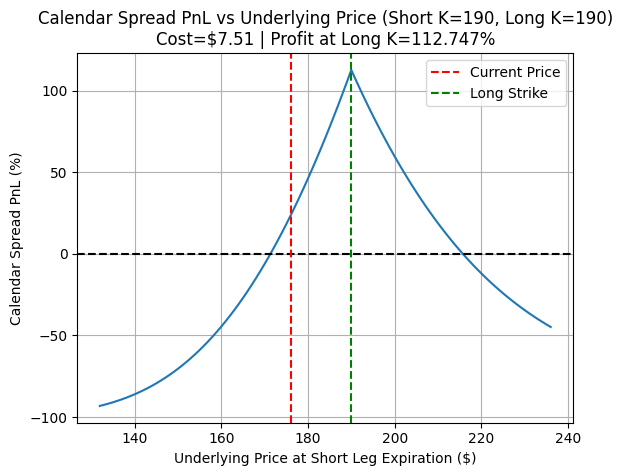

In [235]:
symbol = 'NVDA'
sigma, _, current_price = compute_historical_sigma(symbol, '1D', '2025-01-01', headers=headers)

short_strike = 190
short_dte = 30

long_strike = 190
long_dte = 90

pnl_dict = {}

min_range = min(current_price, short_strike, long_strike)
max_range = max(current_price, short_strike, long_strike)

r = get_risk_free_rate_estimate(long_dte)
sweep_range = range(int(min_range - (0.25 * min_range)),
                    int(max_range + (0.25 * max_range)),
                    1)

# Compute entry prices at entry underlying price (do NOT vary with sweep)
entry_long_prices, long_mat = get_simulated_option_prices_over_dte(strike=long_strike,
                                                     current=current_price,
                                                     dte=long_dte,
                                                     r=r,
                                                     sigma=sigma,
                                                     option_type='call',
                                                     plot=False)
entry_short_prices, short_mat = get_simulated_option_prices_over_dte(strike=short_strike,
                                                      current=current_price,
                                                      dte=short_dte,
                                                      r=r,
                                                      sigma=sigma,
                                                      option_type='call',
                                                      plot=False)
entry_debit = entry_long_prices[long_dte] - entry_short_prices[short_dte]

# Remaining DTE for the long leg when the short expires
remaining_dte = long_dte - short_dte

for current in sweep_range:

    # Value of long leg at short expiry given current underlying
    long_price_dict, _ = get_simulated_option_prices_over_dte(strike=long_strike,
                                                        current=current,
                                                        dte=long_dte,
                                                        r=r,
                                                        sigma=sigma, 
                                                        option_type='call',
                                                        plot=False)
    long_value_at_short_expiry = long_price_dict.get(remaining_dte)

    # Short leg expires: cash settlement equals intrinsic value at expiry
    short_intrinsic = max(current - short_strike, 0)

    # PnL: value of long at short expiry minus cost to settle short and initial net debit
    pnl = long_value_at_short_expiry - short_intrinsic - entry_debit
    pnl_dict[current] = 100 * pnl / entry_debit  # PnL %

plt.plot(pnl_dict.keys(), pnl_dict.values())
plt.xlabel('Underlying Price at Short Leg Expiration ($)')
plt.ylabel('Calendar Spread PnL (%)')
plt.title(f'Calendar Spread PnL vs Underlying Price (Short K={short_strike}, Long K={long_strike})\nCost=${entry_debit:.2f} | Profit at Long K={pnl_dict[long_strike]:.3f}%')
plt.grid()
plt.axhline(0, color='black', linestyle='--')
plt.axvline(current_price, color = 'red', linestyle = '--', label = 'Current Price')
plt.axvline(long_strike, color = 'green', linestyle = '--', label = 'Long Strike')
plt.legend()
plt.show()

In [ ]:
# Sanity check: known Black–Scholes (European) values

S_test = 100.0

K_test = 100.0

T_test = 1.0  # 1 year

r_test = 0.05

sigma_test = 0.2

q_test = 0.0

call_expected = 10.4506  # reference

put_expected = 5.5735   # reference

call_calc = black_scholes_price(S_test, K_test, T_test, r_test, sigma_test, 'call', q_test)

put_calc = black_scholes_price(S_test, K_test, T_test, r_test, sigma_test, 'put', q_test)

print({'call_calc': round(call_calc, 4), 'put_calc': round(put_calc, 4), 'call_expected': call_expected, 'put_expected': put_expected})


{'call_calc': 10.4506, 'put_calc': 5.5735, 'call_expected': 10.4506, 'put_expected': 5.5735}
